In [2]:
!git clone https://github.com/hq-deng/RD4AD.git
%cd RD4AD

Cloning into 'RD4AD'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 68 (delta 39), reused 31 (delta 31), pack-reused 25 (from 1)
Receiving objects: 100% (68/68), 26.21 KiB | 4.37 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/RD4AD


In [3]:
!ls

dataset.py  de_resnet.py  LICENSE  main.py  readme.md  resnet.py  test.py


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!ls /content/drive/MyDrive

 36968760-EECD-4DA8-BFBB-17902AC15E73.jpeg   bottle.tar.xz  'Colab Notebooks'


In [6]:
!ls /content/drive/MyDrive

 36968760-EECD-4DA8-BFBB-17902AC15E73.jpeg   bottle.tar.xz  'Colab Notebooks'


In [7]:
!mkdir -p /content/RD4AD/mvtec
!tar -xJf /content/drive/MyDrive/bottle.tar.xz -C /content/RD4AD/mvtec

In [8]:
!ls /content/RD4AD/mvtec
!ls /content/RD4AD/mvtec/bottle

bottle
ground_truth  license.txt  readme.txt  test  train


In [9]:
!pip install scikit-learn scipy pillow

In [10]:
!ls /content/RD4AD

dataset.py    LICENSE  mvtec	  resnet.py
de_resnet.py  main.py  readme.md  test.py


In [11]:
from pathlib import Path

p = Path("/content/RD4AD/main.py")
txt = p.read_text()

old = """if __name__ == '__main__':
 setup_seed(111)
 item_list = ['carpet', 'bottle', 'hazelnut', 'leather', 'cable', 'capsule', 'grid', 'pill',
 'transistor', 'metal_nut', 'screw','toothbrush', 'zipper', 'tile', 'wood']
 for i in item_list:
  train(i)"""

new = """if __name__ == '__main__':
 setup_seed(111)
 train('bottle')"""

txt = txt.replace(old, new)
p.write_text(txt)

4355

In [12]:
!mkdir -p /content/RD4AD/checkpoints

In [13]:
from pathlib import Path

p = Path("/content/RD4AD/test.py")
txt = p.read_text()
txt = txt.replace("test_path = '../mvtec/' + _class_", "test_path = './mvtec/' + _class_")
p.write_text(txt)

print("test 경로 고침")

test 경로 고침


In [17]:
from pathlib import Path

p = Path("/content/RD4AD/test.py")
txt = p.read_text()
txt = txt.replace(
    "ckp_path = './checkpoints/' + 'rm_1105_wres50_ff_mm_' + _class_ + '.pth'",
    "ckp_path = './checkpoints/' + 'wres50_' + _class_ + '.pth'"
)
p.write_text(txt)

print("체크포인트 이름 고침")

체크포인트 이름 고침


In [18]:
!ls /content/RD4AD/mvtec/bottle
!ls /content/RD4AD/checkpoints

ground_truth  license.txt  readme.txt  test  train


In [19]:
%cd /content/RD4AD
!python main.py

/content/RD4AD
carpet
cuda
Traceback (most recent call last):
  File "/content/RD4AD/main.py", line 120, in <module>
    train(i)
  File "/content/RD4AD/main.py", line 75, in train
    train_data = ImageFolder(root=train_path, transform=data_transform)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/datasets/folder.py", line 328, in __init__
    super().__init__(
  File "/usr/local/lib/python3.12/dist-packages/torchvision/datasets/folder.py", line 149, in __init__
    classes, class_to_idx = self.find_classes(self.root)
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/datasets/folder.py", line 234, in find_classes
    return find_classes(directory)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/datasets/folder.py", line 41, in find_classes
    classes = sorted(entry.name for entry in os.sc

In [20]:
!tail -n 20 /content/RD4AD/main.py

            loss_list.append(loss.item())
        print('epoch [{}/{}], loss:{:.4f}'.format(epoch + 1, epochs, np.mean(loss_list)))
        if (epoch + 1) % 10 == 0:
            auroc_px, auroc_sp, aupro_px = evaluation(encoder, bn, decoder, test_dataloader, device)
            print('Pixel Auroc:{:.3f}, Sample Auroc{:.3f}, Pixel Aupro{:.3}'.format(auroc_px, auroc_sp, aupro_px))
            torch.save({'bn': bn.state_dict(),
                        'decoder': decoder.state_dict()}, ckp_path)
    return auroc_px, auroc_sp, aupro_px




if __name__ == '__main__':

    setup_seed(111)
    item_list = ['carpet', 'bottle', 'hazelnut', 'leather', 'cable', 'capsule', 'grid', 'pill',
                 'transistor', 'metal_nut', 'screw','toothbrush', 'zipper', 'tile', 'wood']
    for i in item_list:
        train(i)



In [27]:
from pathlib import Path

p = Path("/content/RD4AD/main.py")
txt = p.read_text()
txt = txt.replace("epochs = 200", "epochs = 50")
p.write_text(txt)

print("epoch를 50으로 바꿈")

epoch를 50으로 바꿈


In [14]:
from pathlib import Path

p = Path("/content/RD4AD/main.py")
txt = p.read_text()

start = txt.find("if __name__ == '__main__':")
txt = txt[:start] + """if __name__ == '__main__':

    setup_seed(111)
    train('bottle')
"""

p.write_text(txt)

4145

In [29]:
!tail -n 10 /content/RD4AD/main.py

                        'decoder': decoder.state_dict()}, ckp_path)
    return auroc_px, auroc_sp, aupro_px




if __name__ == '__main__':

    setup_seed(111)
    train('bottle')


In [30]:
%cd /content/RD4AD
!python main.py

/content/RD4AD
bottle
cuda
Traceback (most recent call last):
object address  : 0x7b59b80720e0
object refcount : 3
object type     : 0xa284e0
object type name: KeyboardInterrupt
object repr     : KeyboardInterrupt()
lost sys.stderr


In [31]:
from pathlib import Path

p = Path("/content/RD4AD/test.py")
txt = p.read_text()
txt = txt.replace(
    'df = df.append({"pro": mean(pros), "fpr": fpr, "threshold": th}, ignore_index=True)',
    'df.loc[len(df)] = {"pro": mean(pros), "fpr": fpr, "threshold": th}'
)
p.write_text(txt)

print("append 에러 수정 완료")

append 에러 수정 완료


In [32]:
%cd /content/RD4AD
!python main.py

/content/RD4AD
bottle
cuda
epoch [1/50], loss:1.1686
epoch [2/50], loss:0.5789
epoch [3/50], loss:0.3966
epoch [4/50], loss:0.2915
epoch [5/50], loss:0.2313
epoch [6/50], loss:0.2037
epoch [7/50], loss:0.1830
epoch [8/50], loss:0.1651
epoch [9/50], loss:0.1549
epoch [10/50], loss:0.1469
Pixel Auroc:0.982, Sample Auroc0.989, Pixel Aupro0.953
epoch [11/50], loss:0.3649
epoch [12/50], loss:0.1587
epoch [13/50], loss:0.1388
epoch [14/50], loss:0.1322
epoch [15/50], loss:0.1261
epoch [16/50], loss:0.1204
epoch [17/50], loss:0.1191
epoch [18/50], loss:0.1162
epoch [19/50], loss:0.1119
epoch [20/50], loss:0.1143
Pixel Auroc:0.987, Sample Auroc0.998, Pixel Aupro0.967
epoch [21/50], loss:0.1081
epoch [22/50], loss:0.1070
epoch [23/50], loss:0.1040
epoch [24/50], loss:0.1043
epoch [25/50], loss:0.1053
epoch [26/50], loss:0.1068
epoch [27/50], loss:0.1038
epoch [28/50], loss:0.0990
epoch [29/50], loss:0.0948
epoch [30/50], loss:0.0959
Pixel Auroc:0.987, Sample Auroc0.999, Pixel Aupro0.967
epoch [

In [33]:
!ls /content/RD4AD/checkpoints

wres50_bottle.pth


In [34]:
!ls /content/RD4AD/mvtec/bottle/test

broken_large  broken_small  contamination  good


In [35]:
!ls /content/RD4AD/mvtec/bottle/test/broken_large

000.png  003.png  006.png  009.png  012.png  015.png  018.png
001.png  004.png  007.png  010.png  013.png  016.png  019.png
002.png  005.png  008.png  011.png  014.png  017.png


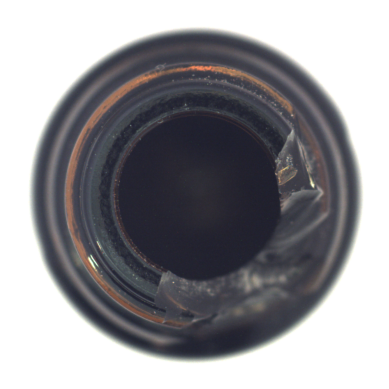

In [36]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/content/RD4AD/mvtec/bottle/test/broken_large/000.png')
plt.imshow(img)
plt.axis('off')
plt.show()

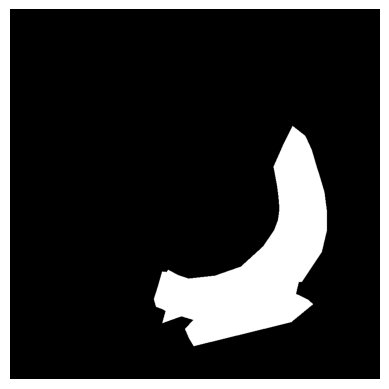

In [37]:
from PIL import Image
import matplotlib.pyplot as plt

mask = Image.open('/content/RD4AD/mvtec/bottle/ground_truth/broken_large/000_mask.png')   # 정답 마스크 열기
plt.imshow(mask, cmap='gray')   # 흑백으로 표시
plt.axis('off')   # 축 숨기기
plt.show()        # 화면에 출력

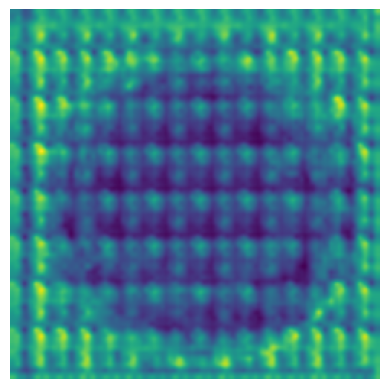

In [38]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

from resnet import resnet18, resnet34, resnet50, wide_resnet50_2
from de_resnet import de_wide_resnet50_2

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 모델 불러오기
encoder, bn = wide_resnet50_2(pretrained=False)
decoder = de_wide_resnet50_2(pretrained=False)

encoder = encoder.to(device)
bn = bn.to(device)
decoder = decoder.to(device)

ckpt = torch.load('/content/RD4AD/checkpoints/wres50_bottle.pth', map_location=device)
bn.load_state_dict(ckpt['bn'])
decoder.load_state_dict(ckpt['decoder'])

encoder.eval()
bn.eval()
decoder.eval()

# 이미지 전처리
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 원본 이미지 열기
img_path = '/content/RD4AD/mvtec/bottle/test/broken_large/000.png'
img = Image.open(img_path).convert('RGB')
x = transform(img).unsqueeze(0).to(device)

# 예측
with torch.no_grad():
    inputs = encoder(x)
    outputs = decoder(bn(inputs))

    anomaly_map = torch.zeros((1, 1, 256, 256)).to(device)
    for i in range(len(inputs)):
        a_map = 1 - F.cosine_similarity(inputs[i], outputs[i], dim=1)
        a_map = a_map.unsqueeze(1)
        a_map = F.interpolate(a_map, size=(256, 256), mode='bilinear', align_corners=False)
        anomaly_map += a_map

    anomaly_map = anomaly_map.squeeze().cpu().numpy()

# 그림 보기
plt.imshow(anomaly_map)
plt.axis('off')
plt.show()

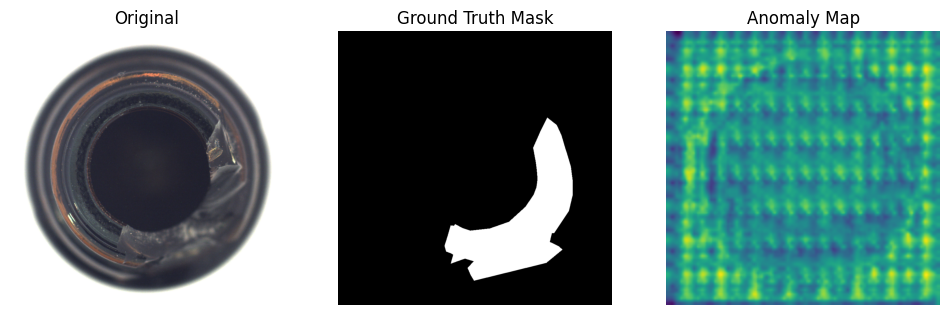

In [39]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

from resnet import wide_resnet50_2
from de_resnet import de_wide_resnet50_2

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 모델 불러오기
encoder, bn = wide_resnet50_2(pretrained=False)
decoder = de_wide_resnet50_2(pretrained=False)

encoder = encoder.to(device)
bn = bn.to(device)
decoder = decoder.to(device)

ckpt = torch.load('/content/RD4AD/checkpoints/wres50_bottle.pth', map_location=device)
bn.load_state_dict(ckpt['bn'])
decoder.load_state_dict(ckpt['decoder'])

encoder.eval()
bn.eval()
decoder.eval()

# 전처리
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 파일 경로
img_path = '/content/RD4AD/mvtec/bottle/test/broken_large/000.png'
mask_path = '/content/RD4AD/mvtec/bottle/ground_truth/broken_large/000_mask.png'

# 원본/마스크 불러오기
img = Image.open(img_path).convert('RGB')
mask = Image.open(mask_path).convert('L')

x = transform(img).unsqueeze(0).to(device)

# anomaly map 계산
with torch.no_grad():
    inputs = encoder(x)
    outputs = decoder(bn(inputs))

    anomaly_map = torch.zeros((1, 1, 256, 256)).to(device)
    for i in range(len(inputs)):
        a_map = 1 - F.cosine_similarity(inputs[i], outputs[i], dim=1)
        a_map = a_map.unsqueeze(1)
        a_map = F.interpolate(a_map, size=(256, 256), mode='bilinear', align_corners=False)
        anomaly_map += a_map

    anomaly_map = anomaly_map.squeeze().cpu().numpy()

# 그림 3개 같이 보기
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title('Ground Truth Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(anomaly_map)
plt.title('Anomaly Map')
plt.axis('off')

plt.show()

In [41]:
%cd /content/RD4AD
!ls

/content/RD4AD
checkpoints  de_resnet.py  main.py  __pycache__  resnet.py
dataset.py   LICENSE	   mvtec    readme.md	 test.py


In [42]:
!ls /content/drive/MyDrive   # 드라이브 안 파일 보기

 36968760-EECD-4DA8-BFBB-17902AC15E73.jpeg   bottle.tar.xz  'Colab Notebooks'


In [43]:
!mkdir -p /content/RD4AD/mvtec   # mvtec 폴더 만들기
!tar -xJf /content/drive/MyDrive/bottle.tar.xz -C /content/RD4AD/mvtec   # bottle 압축 풀기